In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

from readrbdata import load

import matplotlib.pyplot as plt
from fittingutils import *
%matplotlib widget

In [2]:
spike_data = []

In [3]:
sat = load(sat=True, mag=False)
uns = load(sat=False, mag=False)
len(sat.time), len(uns.time)

(13269, 13246)

In [4]:
uns_data_interp = np.interp(sat.time, uns.time, uns.signal)
diff_signal = sat.signal - uns_data_interp

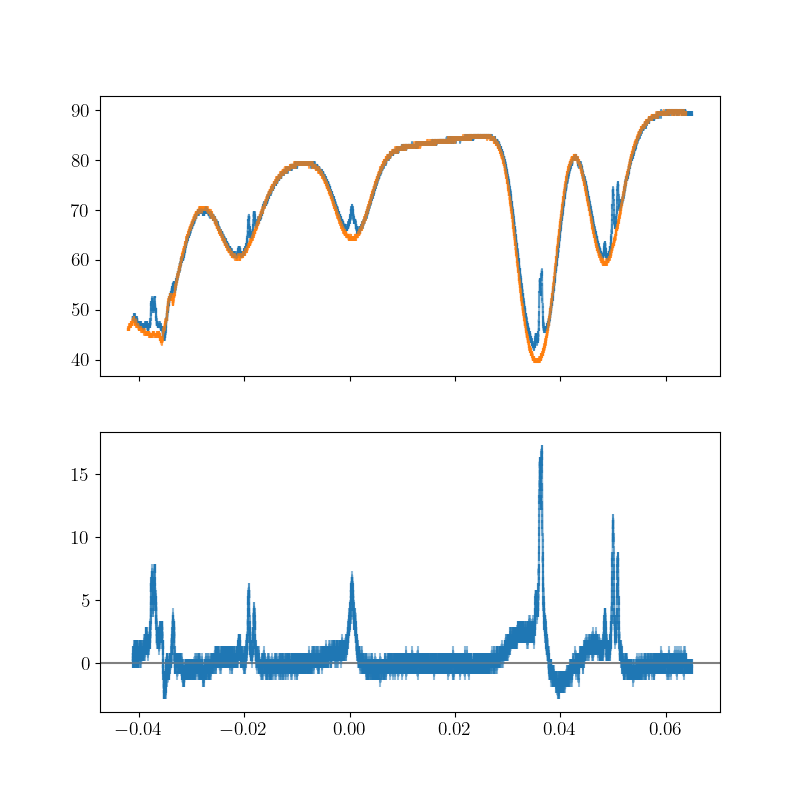

In [5]:
fig, (sig_ax, diff_ax) = plt.subplots(nrows=2, sharex=True, figsize=(8, 8))

sig_ax.errorbar(sat.time, sat.signal, yerr=0.25, alpha=0.5)
sig_ax.errorbar(uns.time, uns.signal, yerr=0.25, alpha=0.5)

diff_ax.errorbar(sat.time, diff_signal, yerr=np.sqrt(2)*0.25, alpha=0.5)
diff_ax.axhline(0., color="gray")

# Fit Ugly One

Fitting this one all at once just because they're so close together

In [6]:
def triple_lorentzian(x, x00, g0, a0, x01, g1, a1, x02, g2, a2, offset):
    return Lorentzian(x, x00, g0, a0, 0.) + Lorentzian(x, x01, g1, a1, 0.) + Lorentzian(x, x02, g2, a2, 0.) + offset

p0 = [0.0353802059, 0.000269989313, 2.86606797, 0.0361253841, 0.000148795328, 11.604702, 0.036486919, 0.000175914349, 13.6402594, 1.30696023]
fit params:
[3.53802030e-02 2.70037082e-04 2.86595284e+00 3.61253841e-02
 1.48792446e-04 1.16046473e+01 3.64869185e-02 1.75916270e-04
 1.36403187e+01 1.30689892e+00]
cov:
[[ 2.13051897e-10  5.81158290e-11 -4.93053268e-08  1.15362094e-12
  -2.55666017e-11 -1.23527935e-07 -5.21235569e-12  2.88245077e-12
   3.90014932e-07  4.56820132e-08]
 [ 5.81158290e-11  7.11398801e-10 -1.65420298e-06 -9.21660505e-13
  -5.61047589e-11 -8.41245419e-07 -1.11345638e-11  3.05784598e-11
   1.07728179e-06 -8.58819024e-07]
 [-4.93053268e-08 -1.65420298e-06  2.19843587e-02 -3.31848006e-08
  -6.49957182e-08  1.99164249e-03 -1.54322618e-08  7.71550758e-08
   3.25077638e-03 -2.02997798e-03]
 [ 1.15362094e-12 -9.21660505e-13 -3.31848006e-08  1.09467878e-11
   8.19588864e-12  1.97923052e-07  5.83283831e-12 -8.04493925e-12
  -2.45665929e-07  2.65133477e-08]
 [-2.55666017e-11 -

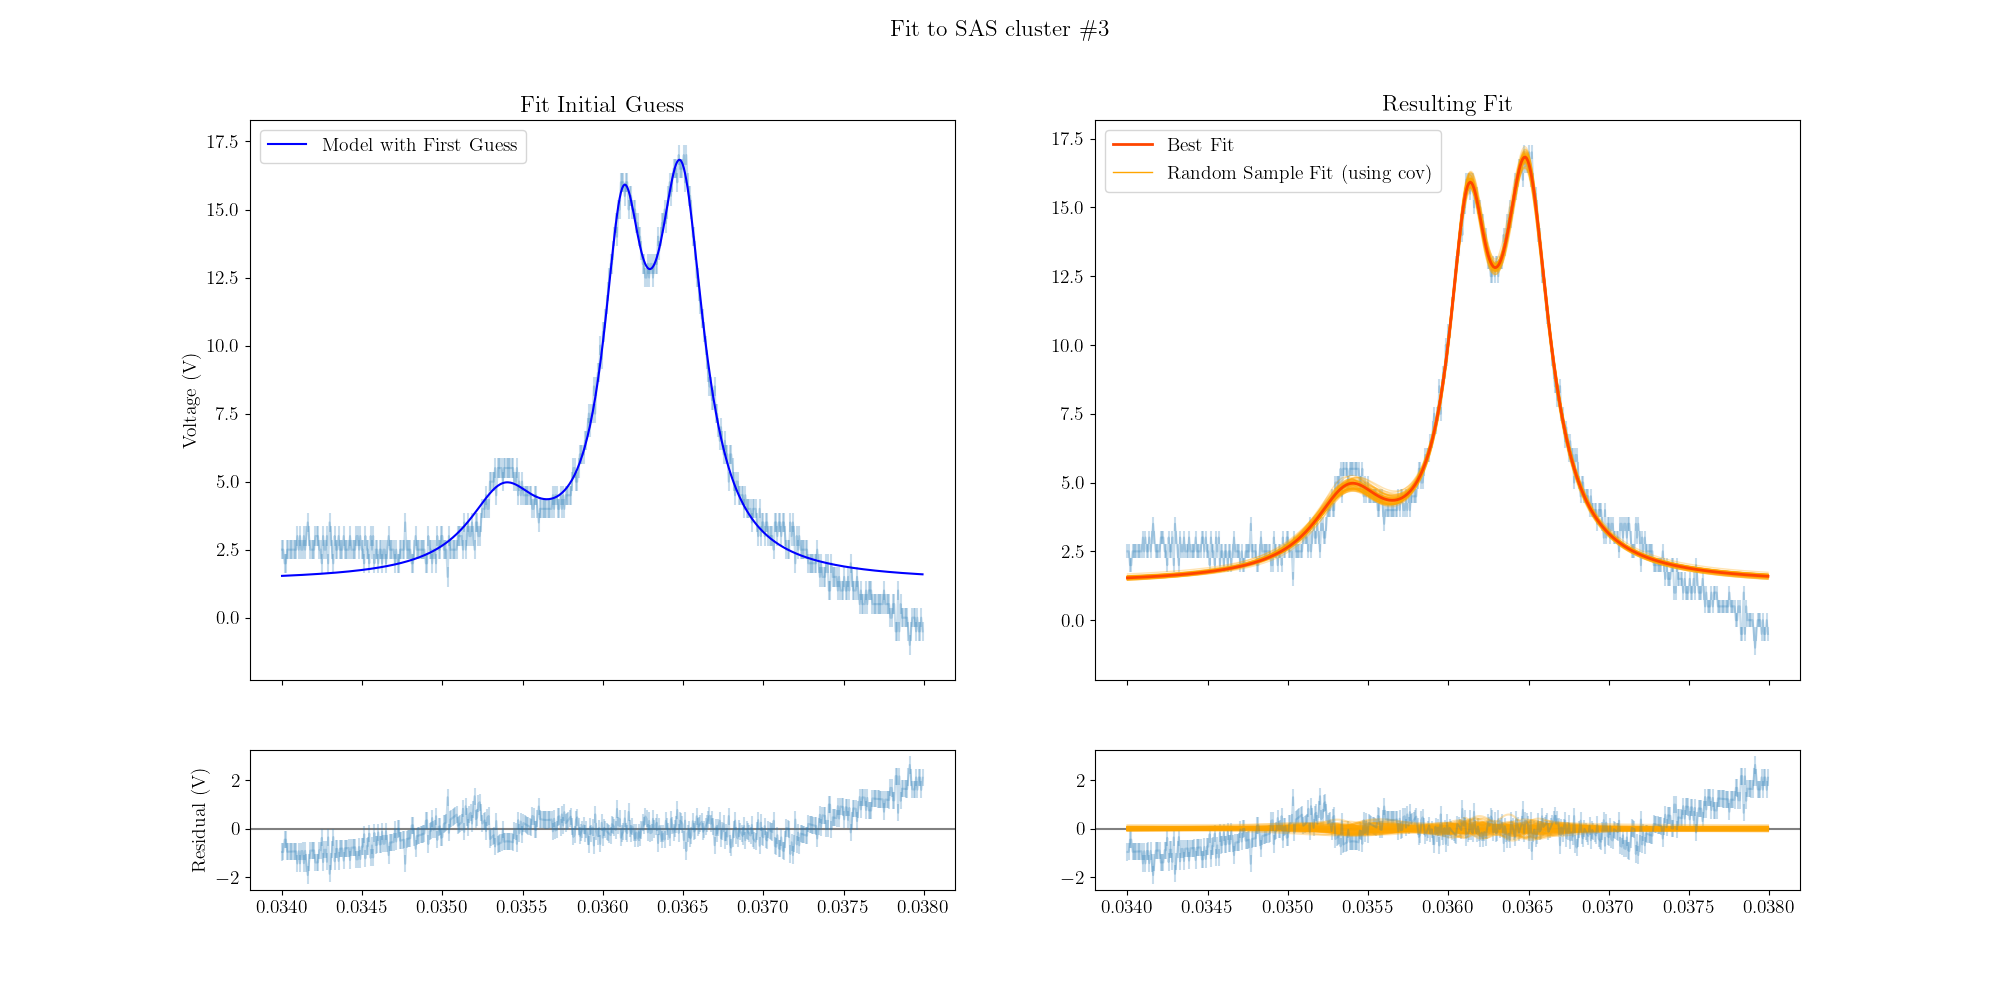

In [7]:
x_low = .034
x_high = .038
cluster_n = 2

# MAKE PLOTS
fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(20, 10))

# ESTABLISH INITIAL GUESSES
spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

x = sat.time[spidx]
y = diff_signal[spidx]

baseline_guess = 2.5

p0 = [
    3.53802059e-02, 
    2.69989313e-04, 
    2.86606797e+00, 
    
    3.61253841e-02,
    1.48795328e-04, 
    1.16047020e+01, 
    
    3.64869190e-02, 
    1.75914349e-04,
    1.36402594e+01, 
    
    1.30696023e+00
]
print(f"{p0 = }")

guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
guess_data_ax.plot(x, triple_lorentzian(x, *p0), zorder=10, color='blue', label='Model with First Guess')

# guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
# guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3])/2, (p0[2] + p0[3])/2], color='green', alpha=0.5, label='FWHM guess')
# guess_data_ax.axhline(p0[2] + p0[3], label='amplitude guess', c='red', alpha=0.5)
# guess_data_ax.axhline(p0[3], label='baseline guess', c='red', alpha=0.5)

guess_data_ax.set_title('Fit Initial Guess')
guess_data_ax.set_ylabel('Voltage (V)')
guess_data_ax.legend()

residuals = triple_lorentzian(x, *p0) - y

guess_res_ax.axhline(0., color='gray')
guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
guess_res_ax.set_ylabel('Residual (V)')
# guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))

fit_params, cov = curve_fit(triple_lorentzian, x, y, p0, np.sqrt(2)*0.25)
print(f"fit params:\n{fit_params}")
print(f"cov:\n{cov}")

fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
data_y_lims = fit_data_ax.set_ylim()

random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
for fit_sample in random_fit_samples:
    fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, alpha=0.3)
fit_data_ax.plot(x, triple_lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Random Sample Fit (using cov)')

fit_data_ax.legend()

fit_data_ax.set_ylim(data_y_lims)
fit_data_ax.set_title('Resulting Fit')

residuals = triple_lorentzian(x, *fit_params) - y

fit_res_ax.axhline(0., color='gray')
fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
for fit_sample in random_fit_samples:
    fit_res_ax.plot(x, triple_lorentzian(x, *fit_sample) - triple_lorentzian(x, *fit_params), c='orange', alpha=0.3)

fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')

for i in range(3):
    this_spike = {
        "center_time": fit_params[0 + i*3],
        "e_center_time": np.sqrt(np.diag(cov))[0 + i*3],
        "amplitude": fit_params[2 + i*3],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")

In [8]:
def fit_spike(x_low, x_high, cluster_n):
    # MAKE PLOTS
    fig, ((guess_data_ax, fit_data_ax), (guess_res_ax, fit_res_ax)) = plt.subplots(2, 2, sharex=True, height_ratios=[4, 1], figsize=(20, 10))

    # ESTABLISH INITIAL GUESSES
    spidx, = np.nonzero((x_low <= sat.time) & (sat.time < x_high)) # single peak indices

    x = sat.time[spidx]
    y = diff_signal[spidx]

    baseline_guess = np.quantile(y, 0.3)

    p0 = [
        x[np.argmax(diff_signal[spidx])],
        Lorentzian.guess_gamma(x, y),
        np.max(y) - baseline_guess,
        baseline_guess
    ]
    print(f"{p0 = }")

    guess_data_ax.errorbar(x, y, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_data_ax.plot(x, Lorentzian(x, *p0), zorder=10, color='blue')

    guess_data_ax.axvline(p0[0], label='x0 guess', c='red', alpha=0.5)
    guess_data_ax.plot([p0[0] - p0[1], p0[0] + p0[1]], [(p0[2] + p0[3])/2, (p0[2] + p0[3])/2], color='green', alpha=0.5, label='FWHM guess')
    guess_data_ax.axhline(p0[2] + p0[3], label='amplitude guess', c='red', alpha=0.5)
    guess_data_ax.axhline(p0[3], label='baseline guess', c='red', alpha=0.5)

    guess_data_ax.set_title('Fit Initial Guess')
    guess_data_ax.set_ylabel('Voltage (V)')
    guess_data_ax.legend()

    residuals = Lorentzian(x, *p0) - y

    guess_res_ax.axhline(0., color='gray')
    guess_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    guess_res_ax.set_ylabel('Residual (V)')
    # guess_res_ax.set_ylim(np.min(residuals), np.max(residuals))
    
    fit_params, cov = curve_fit(Lorentzian, x, y, p0, np.sqrt(2)*0.25)
    print(f"fit params:\n{fit_params}")
    print(f"cov:\n{cov}")

    fit_data_ax.errorbar(x, y, yerr=0.25, alpha=0.25)
    fit_data_ax.plot(x, Lorentzian(x, *fit_params), lw=2, c='orangered', zorder=10, label='Best Fit')
    data_y_lims = fit_data_ax.set_ylim()

    random_fit_samples = np.random.multivariate_normal(fit_params, cov, 64)
    for fit_sample in random_fit_samples:
        fit_data_ax.plot(x, Lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5)
    fit_data_ax.plot(x, Lorentzian(x, *fit_sample), lw=1, c='orange', zorder=5, label='Random Sample Fit (using cov)')
    
    fit_data_ax.legend()

    fit_data_ax.set_ylim(data_y_lims)
    fit_data_ax.set_title('Resulting Fit')

    residuals = Lorentzian(x, *fit_params) - y

    fit_res_ax.axhline(0., color='gray')
    fit_res_ax.errorbar(x, residuals, yerr=np.sqrt(2)*0.25, alpha=0.25)
    for fit_sample in random_fit_samples:
        fit_res_ax.plot(x, Lorentzian(x, *fit_sample) - Lorentzian(x, *fit_params), c='orange')

    fig.suptitle(f'Fit to SAS cluster \\#{cluster_n + 1}')
    np.sqrt(np.diag(cov))
    this_spike = {
        "center_time": fit_params[0],
        "e_center_time": np.sqrt(np.diag(cov))[0],
        "amplitude": fit_params[2],
        "cluster_id": cluster_n
    }

    print(f"{this_spike = }")

    if this_spike not in spike_data:
        spike_data.append(this_spike)
    else:
        print('SPIKE NOT APPENDED, WE ALREADY GOT THIS ONE')

    print(f"{len(spike_data) = }")

p0 = [-0.021064, 0.00010000000000000113, 1.5, 0.5]
fit params:
[-2.09736804e-02  1.66587380e-04  1.71266141e+00  2.22976941e-01]
cov:
[[ 5.31551121e-11 -8.61709088e-14 -2.04461794e-10  3.76636836e-10]
 [-8.61709088e-14  1.93259563e-10 -4.30916375e-07 -3.10659802e-07]
 [-2.04461794e-10 -4.30916375e-07  5.81165741e-03 -4.43070592e-04]
 [ 3.76636836e-10 -3.10659802e-07 -4.43070592e-04  1.13279018e-03]]
this_spike = {'center_time': -0.020973680426589713, 'e_center_time': 7.290755250123568e-06, 'amplitude': 1.7126614134975477, 'cluster_id': 0}
len(spike_data) = 4


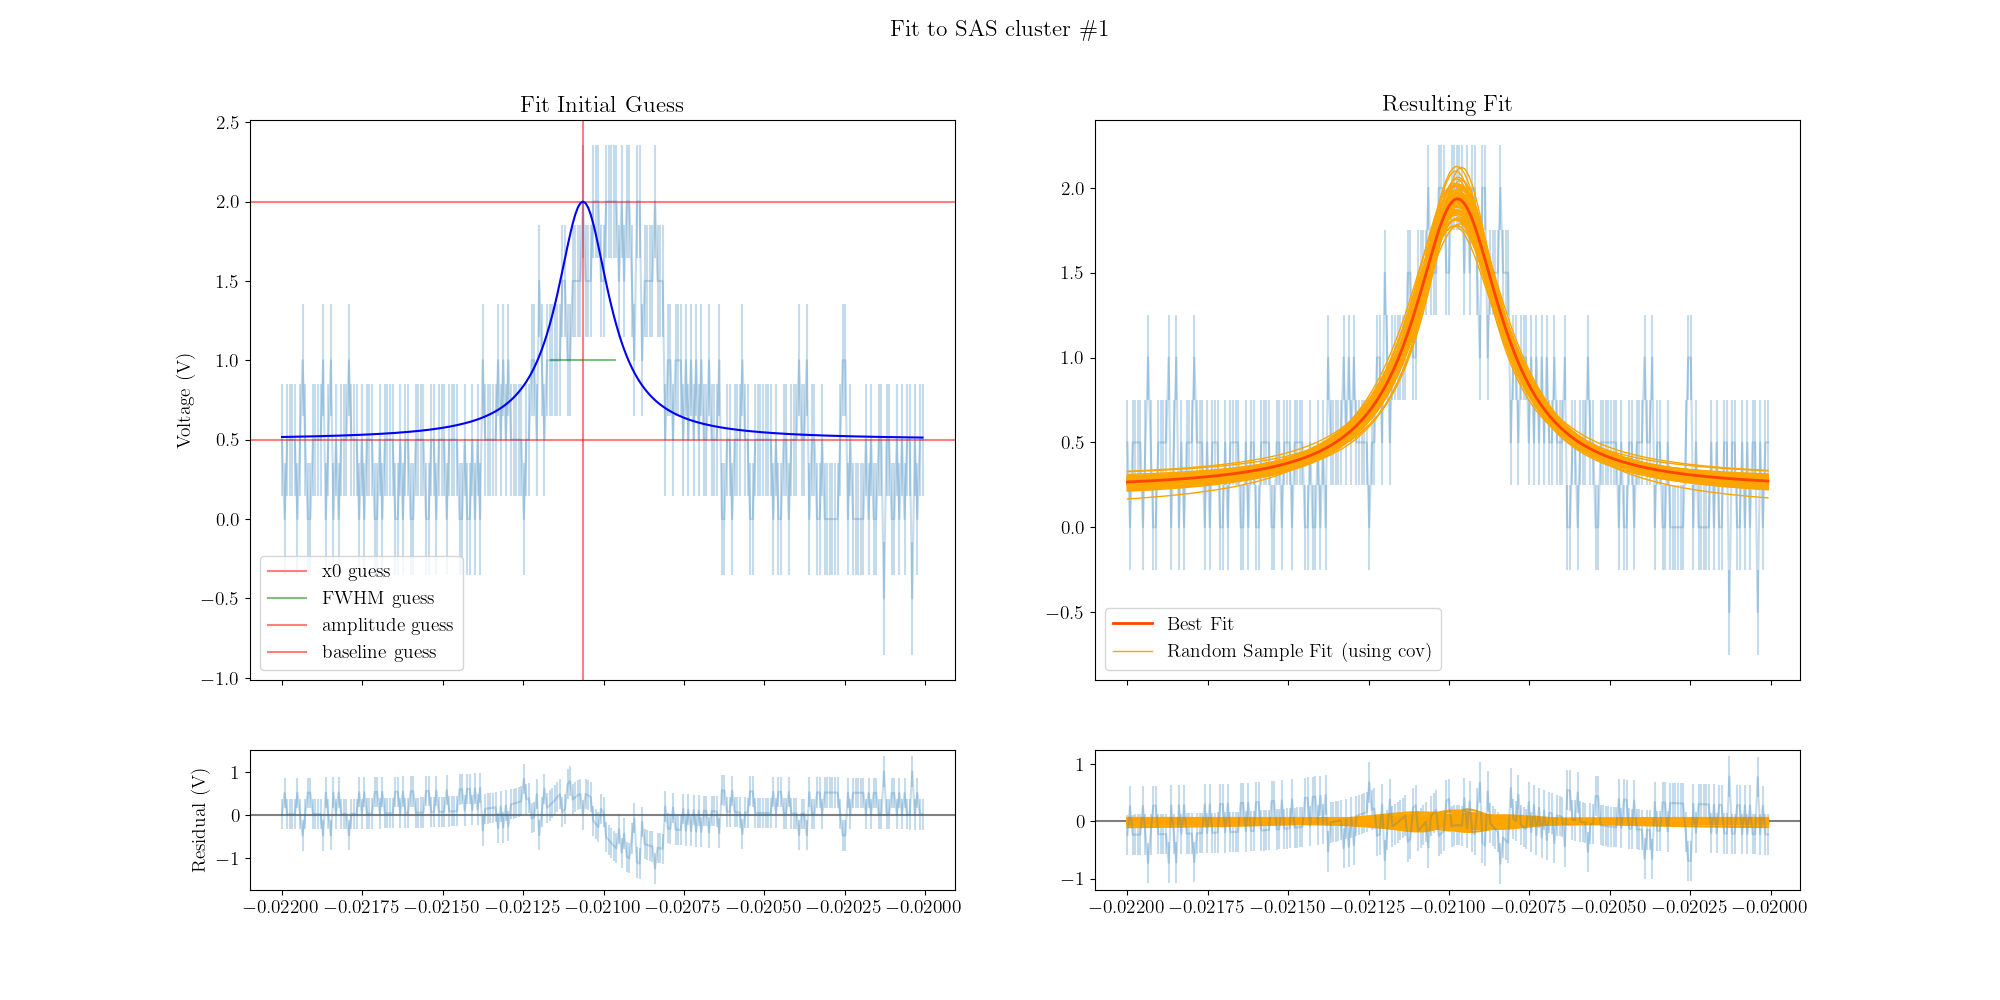

In [9]:
fit_spike(-.022, -.02, 0)

p0 = [-0.019136, 0.00015199999999999936, 5.0, 1.0]
fit params:
[-1.91518758e-02  1.77229581e-04  5.70767385e+00  9.28371067e-02]
cov:
[[ 5.86107842e-12 -2.40423698e-13 -3.26855195e-09  4.44754684e-09]
 [-2.40423698e-13  2.87097945e-11 -7.12541661e-08 -2.25870301e-07]
 [-3.26855195e-09 -7.12541661e-08  7.10446166e-03 -1.74117068e-03]
 [ 4.44754684e-09 -2.25870301e-07 -1.74117068e-03  3.14389507e-03]]
this_spike = {'center_time': -0.019151875843380132, 'e_center_time': 2.4209664223216253e-06, 'amplitude': 5.707673850607473, 'cluster_id': 0}
len(spike_data) = 5


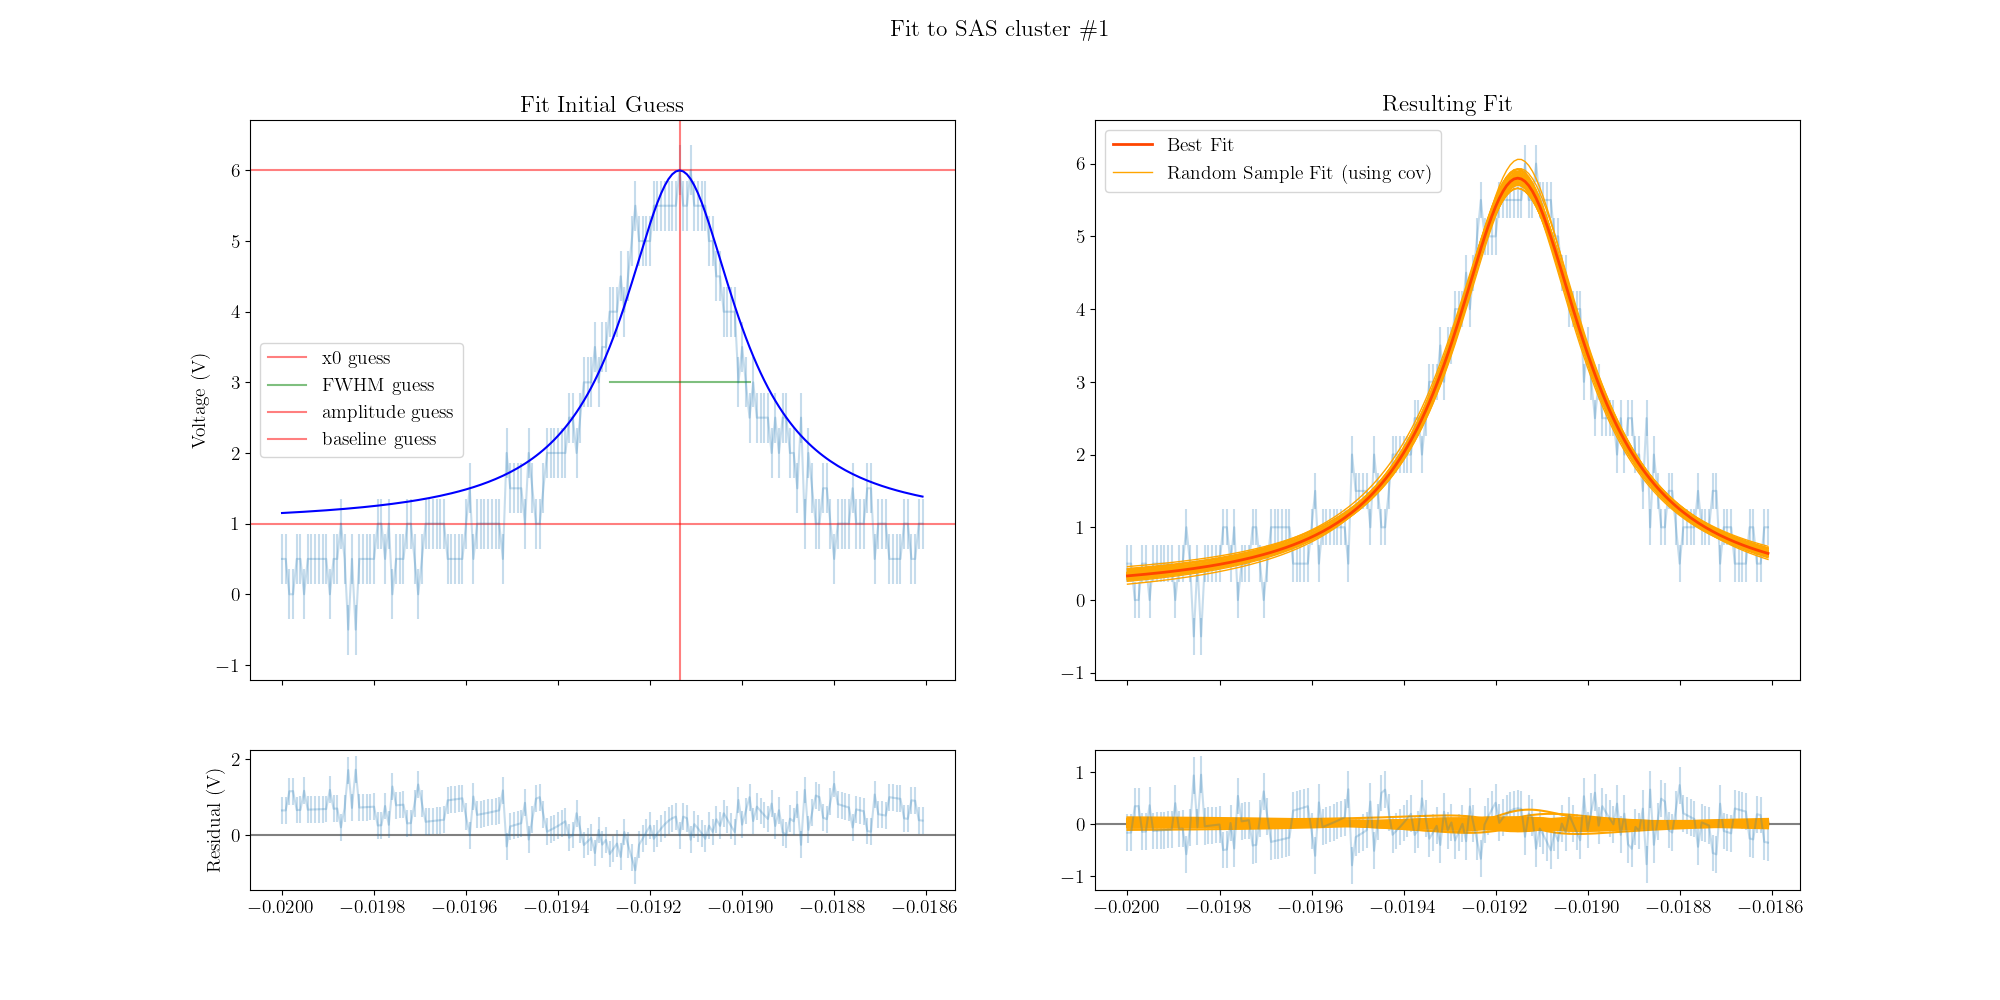

In [10]:
fit_spike(-.02, -.01860, 0)

p0 = [-0.018144, 0.00015199999999999936, 4.0, 0.5]
fit params:
[-1.81231932e-02  1.74145719e-04  4.16007032e+00 -5.32656639e-02]
cov:
[[ 1.18044946e-11  6.55619760e-13  7.52915758e-09 -9.72957063e-09]
 [ 6.55619760e-13  7.83070190e-11  8.66117561e-08 -6.07666924e-07]
 [ 7.52915758e-09  8.66117561e-08  9.69451360e-03 -4.49116539e-03]
 [-9.72957063e-09 -6.07666924e-07 -4.49116539e-03  7.06397514e-03]]
this_spike = {'center_time': -0.0181231931698914, 'e_center_time': 3.435766965537419e-06, 'amplitude': 4.160070316068849, 'cluster_id': 0}
len(spike_data) = 6


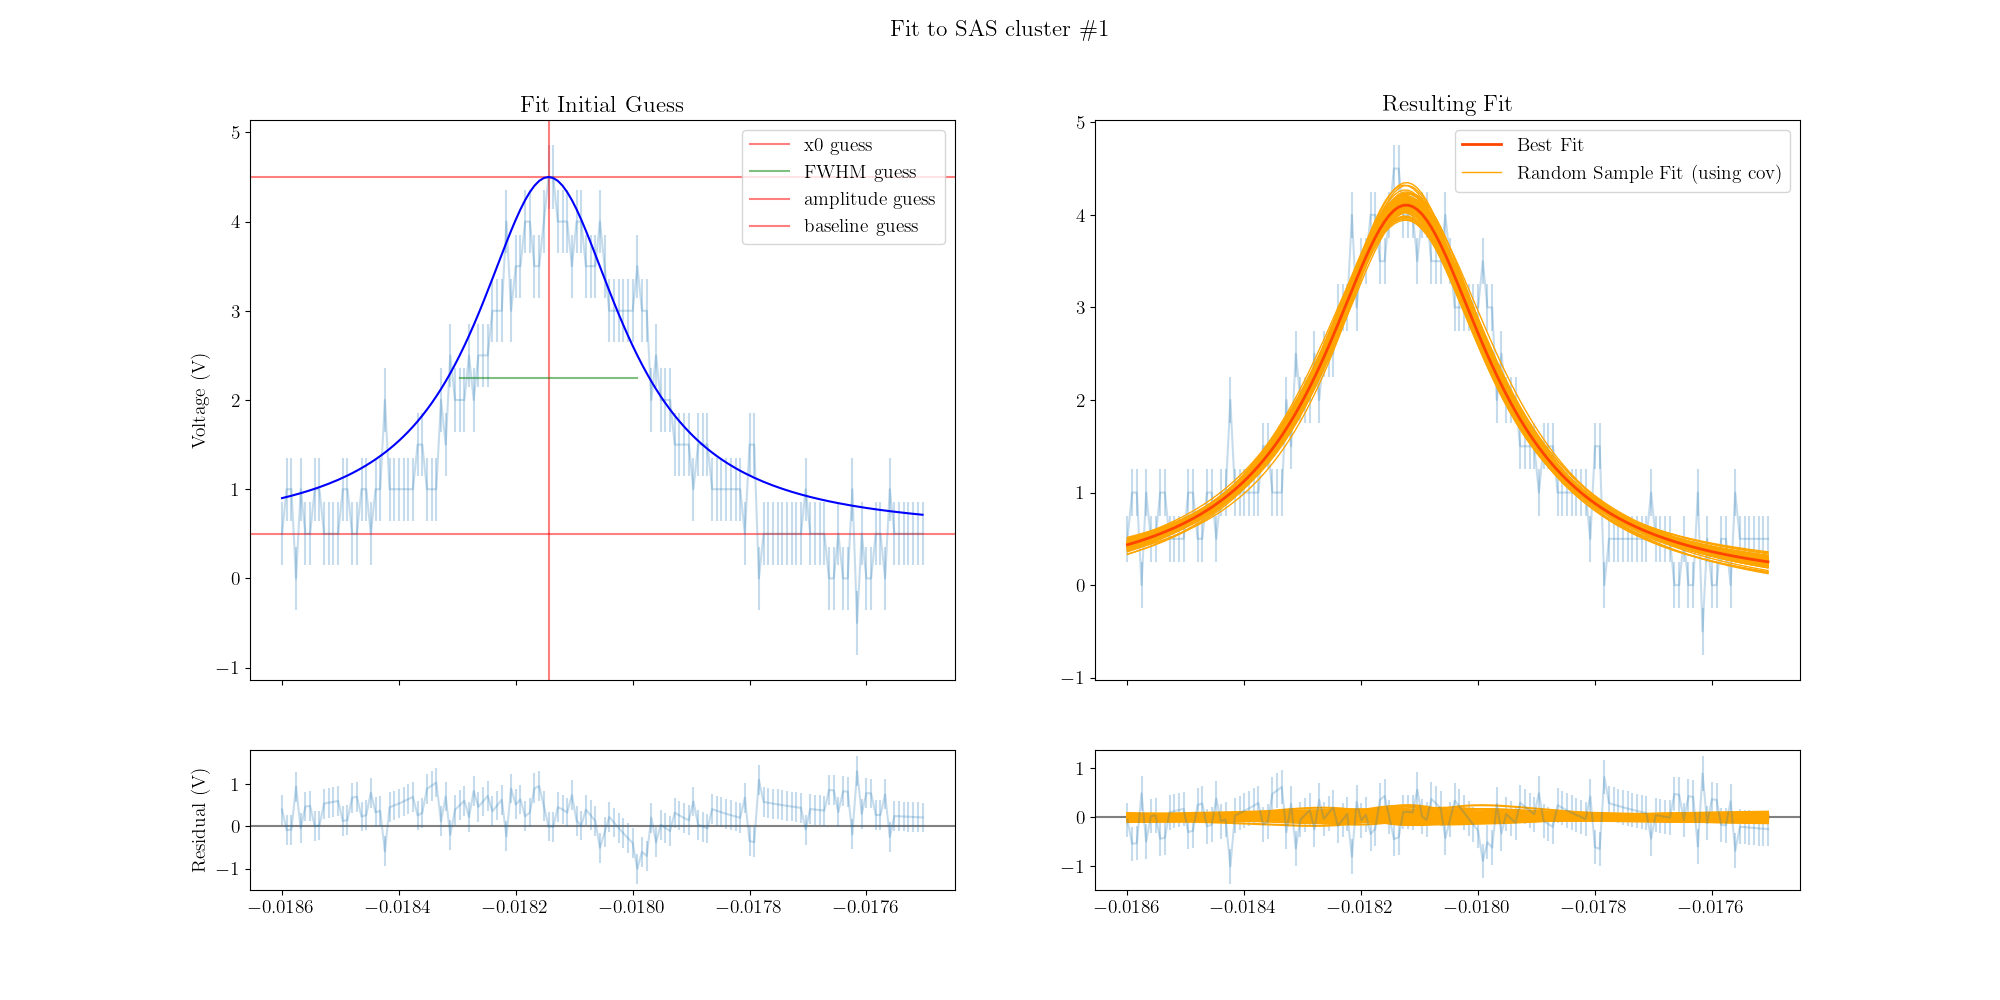

In [11]:
fit_spike(-.01860, -.01750, 0)

p0 = [0.000472, 0.000288, 6.5, 0.5]
fit params:
[4.46728302e-04 4.99815712e-04 5.81471915e+00 2.23654533e-01]
cov:
[[ 4.62433354e-11 -1.08469828e-13 -2.22462469e-10  4.83348650e-10]
 [-1.08469828e-13  1.42425402e-10 -4.83763614e-07 -1.86044780e-07]
 [-2.22462469e-10 -4.83763614e-07  6.33492972e-03 -2.15168211e-04]
 [ 4.83348650e-10 -1.86044780e-07 -2.15168211e-04  7.03059437e-04]]
this_spike = {'center_time': 0.00044672830186199273, 'e_center_time': 6.800245242105157e-06, 'amplitude': 5.814719145914962, 'cluster_id': 1}
len(spike_data) = 7


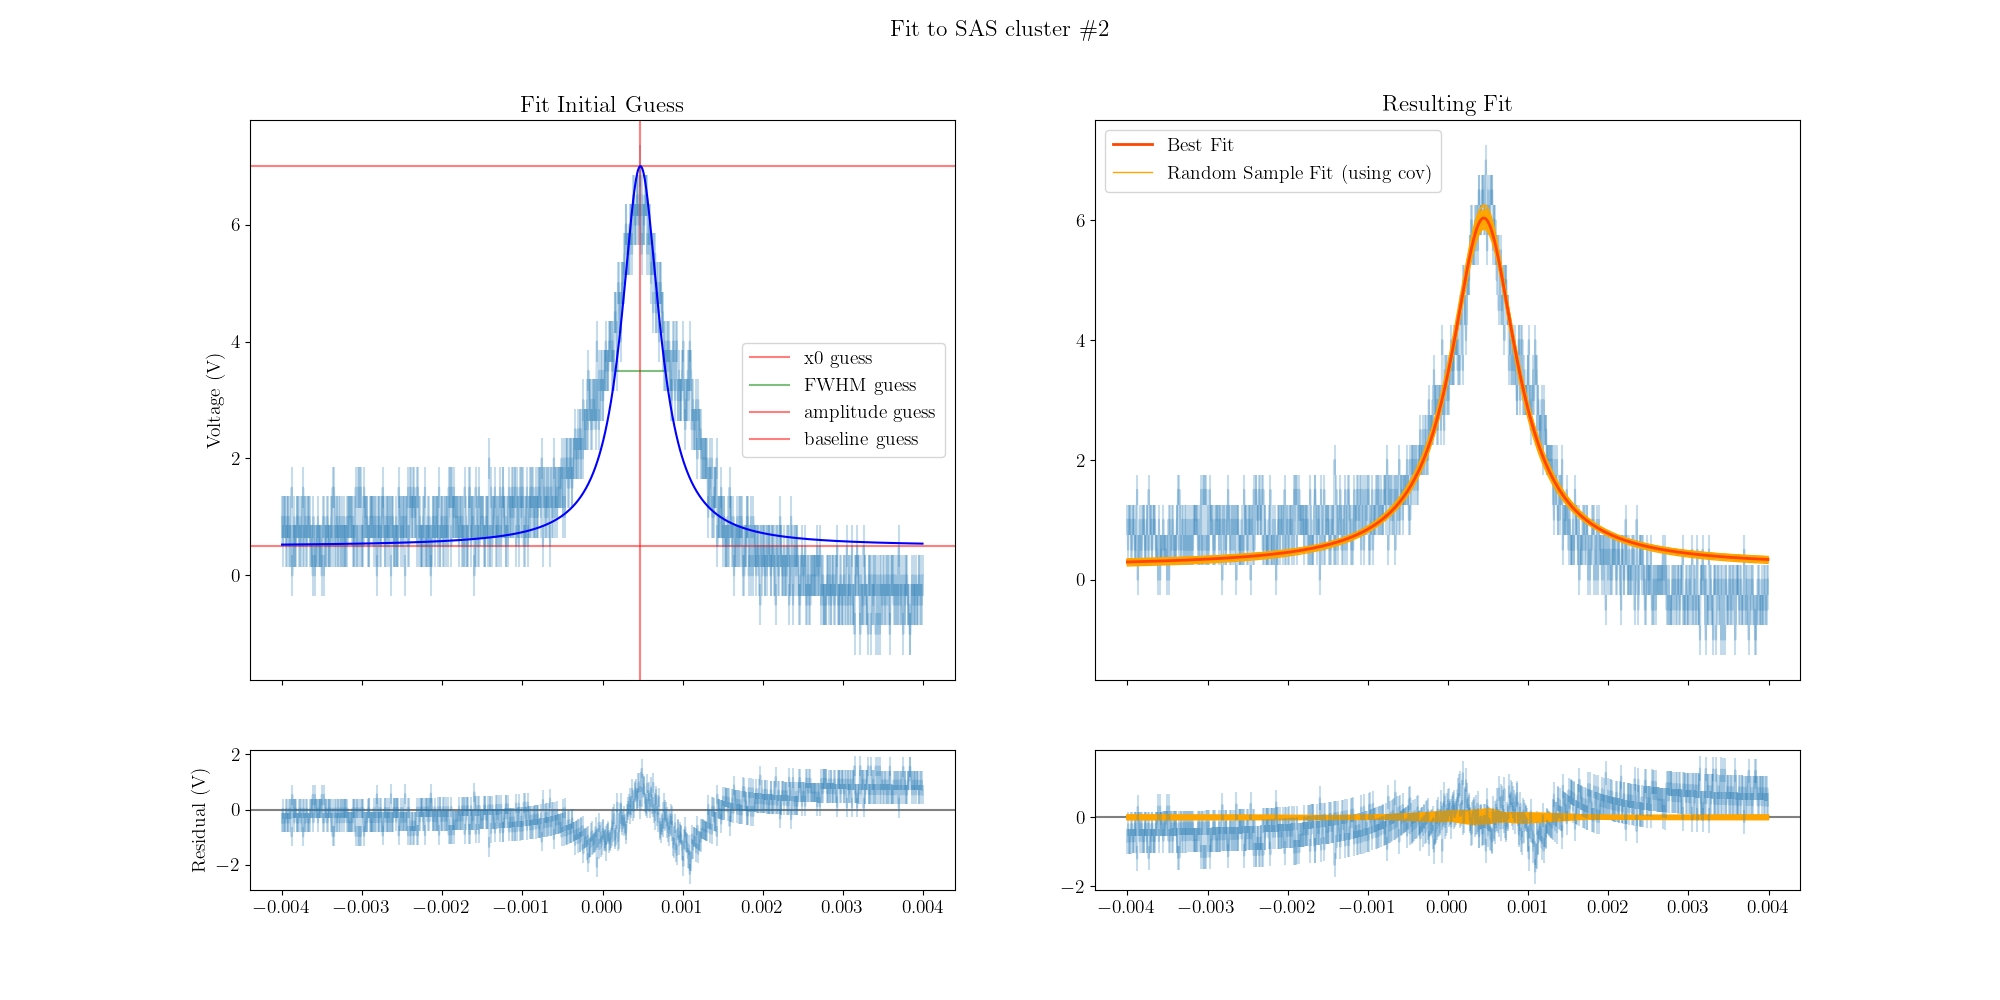

In [12]:
fit_spike(-.004, .004, 1)

p0 = [0.048448, 0.0001360000000000007, 3.0, 1.0]
fit params:
[4.84790125e-02 1.54595594e-04 3.23324662e+00 7.23101520e-01]
cov:
[[ 1.69332707e-11 -7.72136043e-14 -4.70432590e-10  7.61953590e-10]
 [-7.72136043e-14  7.25038181e-11 -2.18786568e-07 -3.04298218e-07]
 [-4.70432590e-10 -2.18786568e-07  7.98930257e-03 -1.15202263e-03]
 [ 7.61953590e-10 -3.04298218e-07 -1.15202263e-03  2.46261652e-03]]
this_spike = {'center_time': 0.04847901254228282, 'e_center_time': 4.115005548524093e-06, 'amplitude': 3.2332466224391907, 'cluster_id': 3}
len(spike_data) = 8


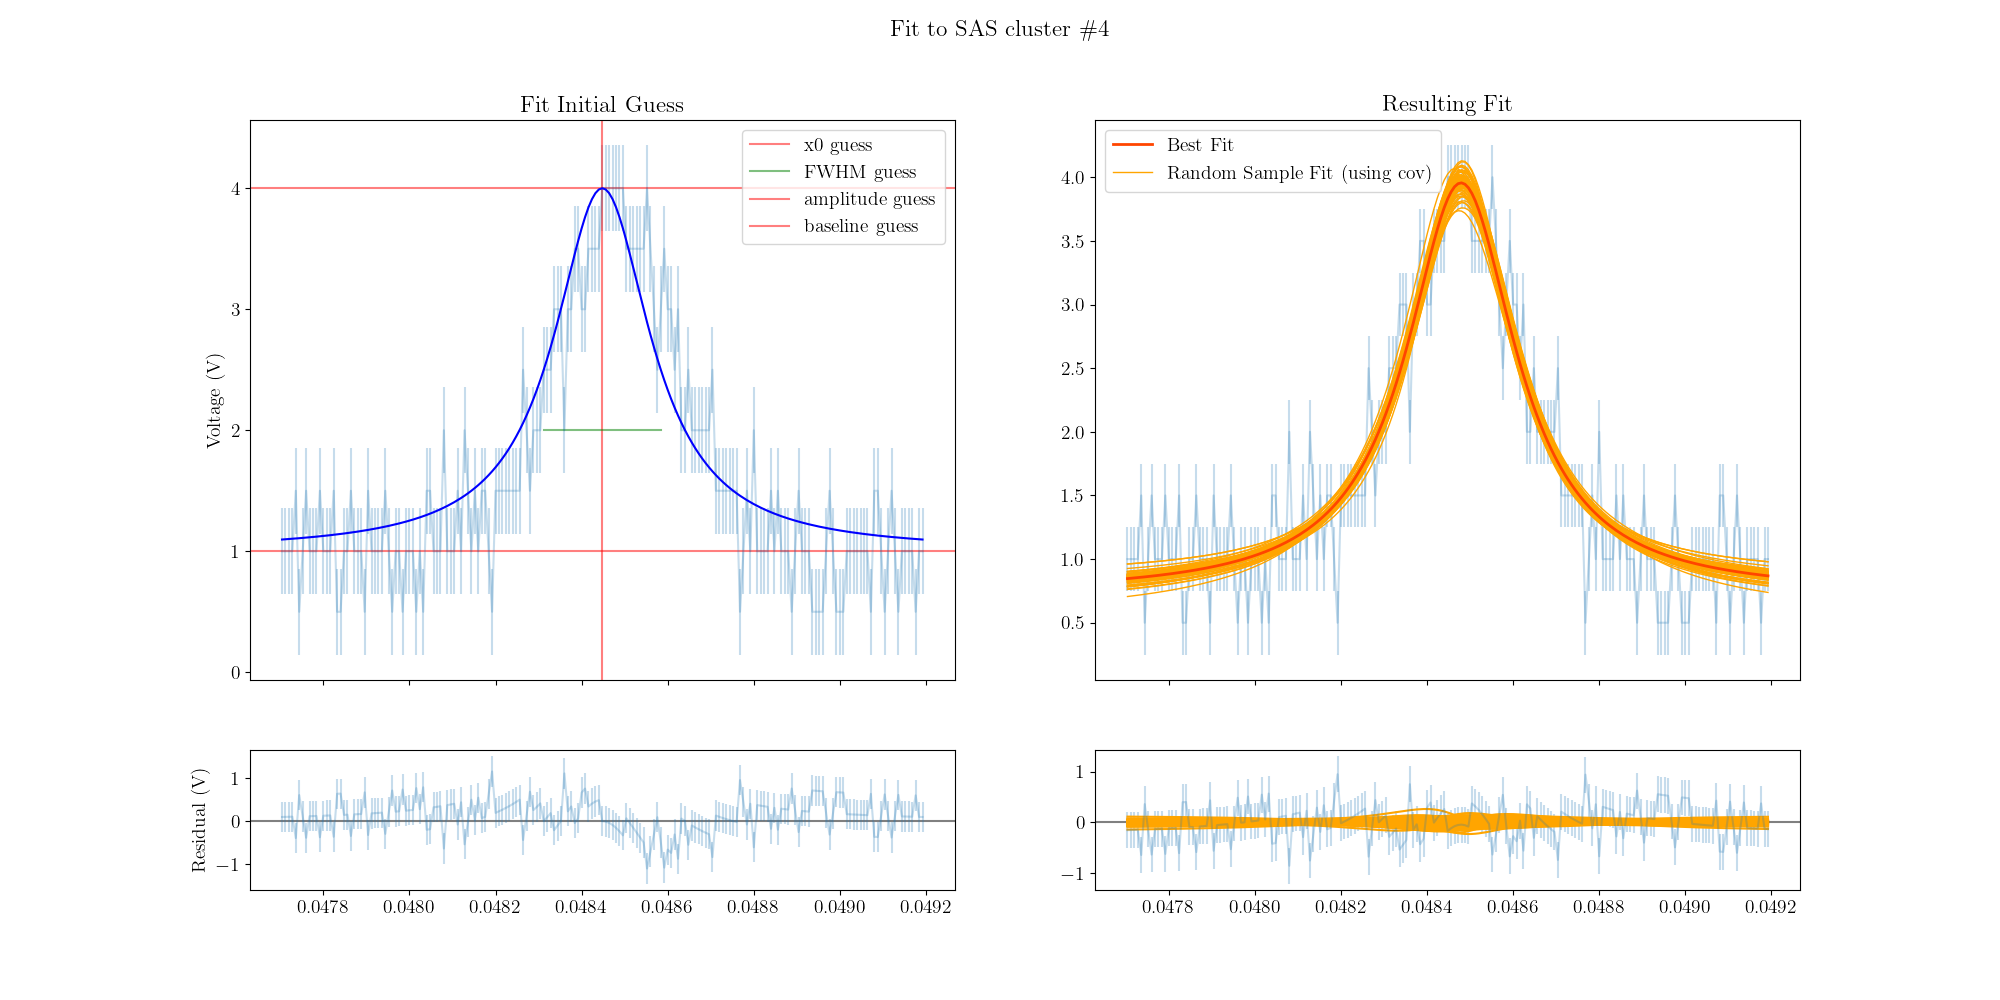

In [13]:
fit_spike(.0477, .0492, 3)

p0 = [0.05004, 0.00018400000000000014, 10.0, 1.5]
fit params:
[5.00288395e-02 1.83538528e-04 1.07646092e+01 4.84308276e-01]
cov:
[[ 2.06689675e-12 -7.52603137e-14 -1.92904373e-09  2.58715983e-09]
 [-7.52603137e-14  8.92062721e-12 -6.76194400e-08 -1.10746625e-07]
 [-1.92904373e-09 -6.76194400e-08  7.91261459e-03 -1.41345737e-03]
 [ 2.58715983e-09 -1.10746625e-07 -1.41345737e-03  2.69903392e-03]]
this_spike = {'center_time': 0.050028839508674164, 'e_center_time': 1.437670599256419e-06, 'amplitude': 10.764609170895758, 'cluster_id': 3}
len(spike_data) = 9


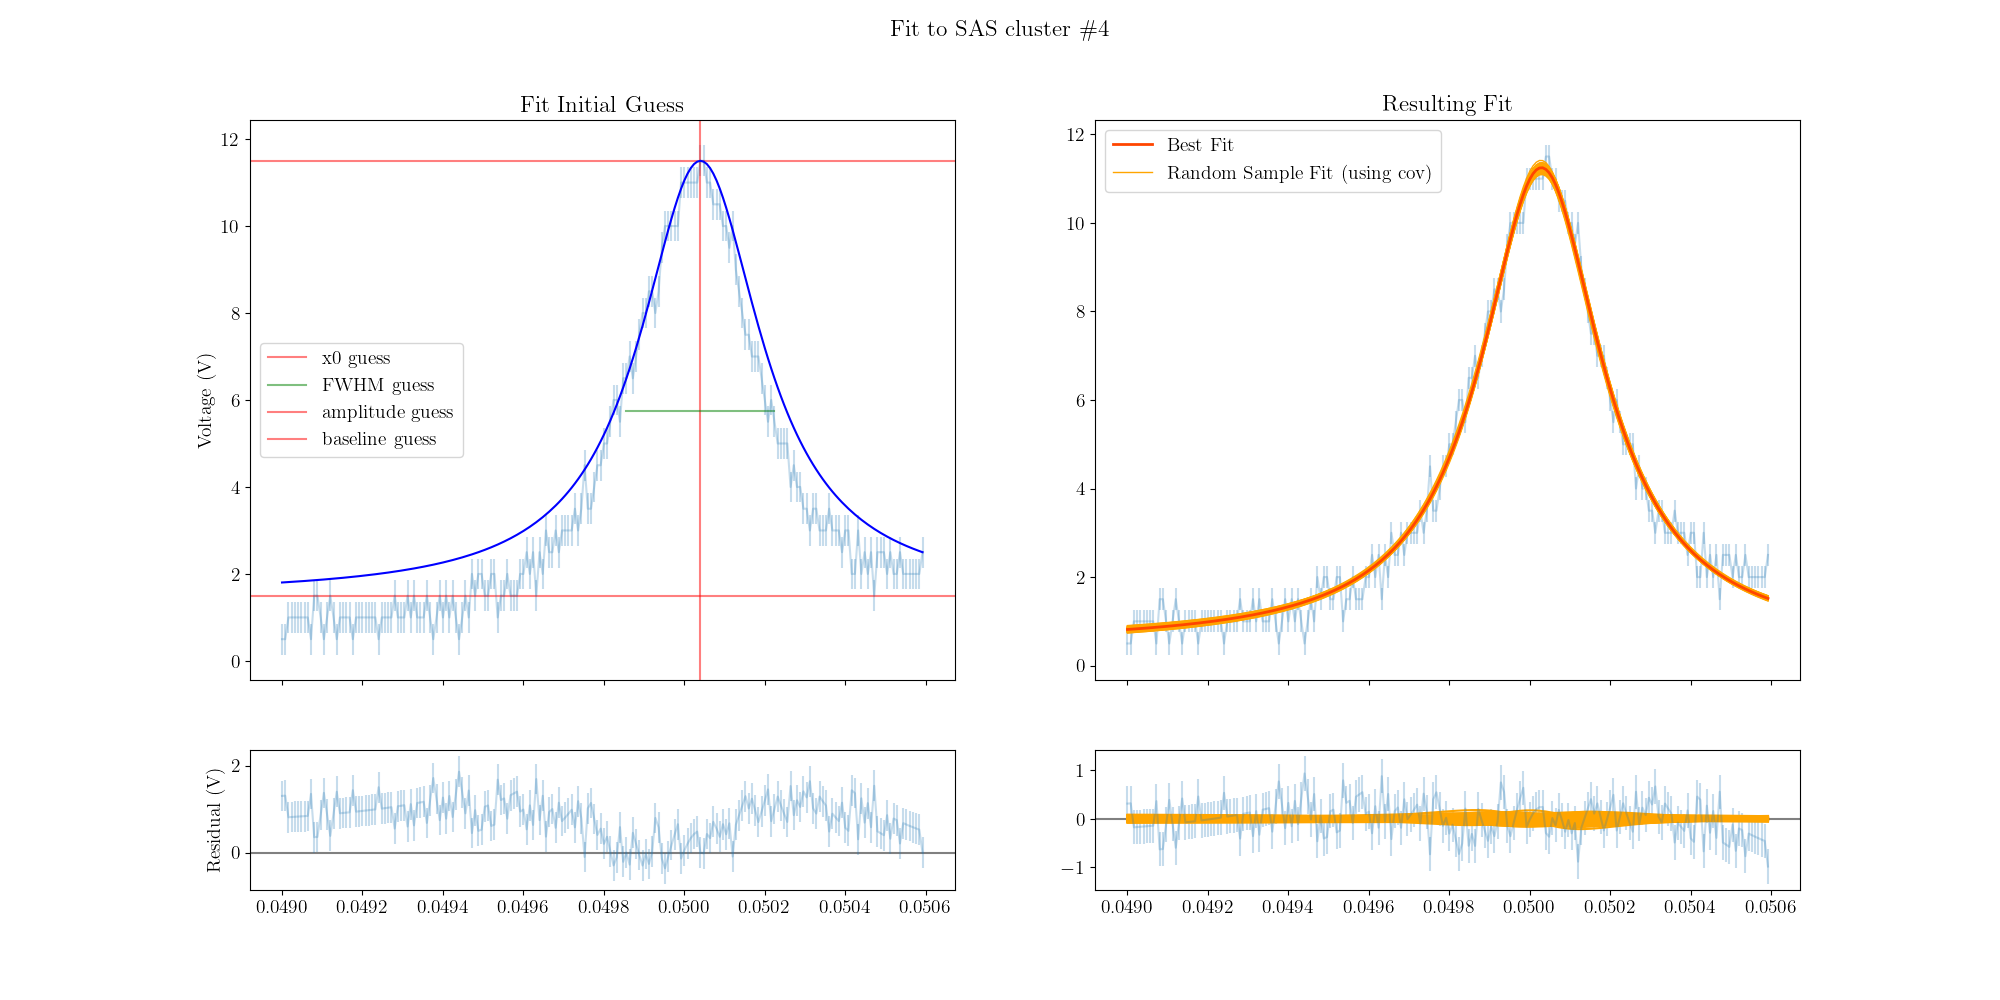

In [14]:
fit_spike(.04900, .0506, 3)

p0 = [0.050912, 0.00017199999999999854, 6.5, 2.0]
fit params:
[5.09214659e-02 1.72860931e-04 8.26324880e+00 8.32406266e-02]
cov:
[[ 4.39454397e-12  3.80363269e-13  9.91439070e-09 -1.22446381e-08]
 [ 3.80363269e-13  3.24095988e-11  1.45440632e-07 -5.53965599e-07]
 [ 9.91439070e-09  1.45440632e-07  1.63770337e-02 -9.18232238e-03]
 [-1.22446381e-08 -5.53965599e-07 -9.18232238e-03  1.36681649e-02]]
this_spike = {'center_time': 0.050921465890227065, 'e_center_time': 2.0963167618766785e-06, 'amplitude': 8.263248797699697, 'cluster_id': 3}
len(spike_data) = 10


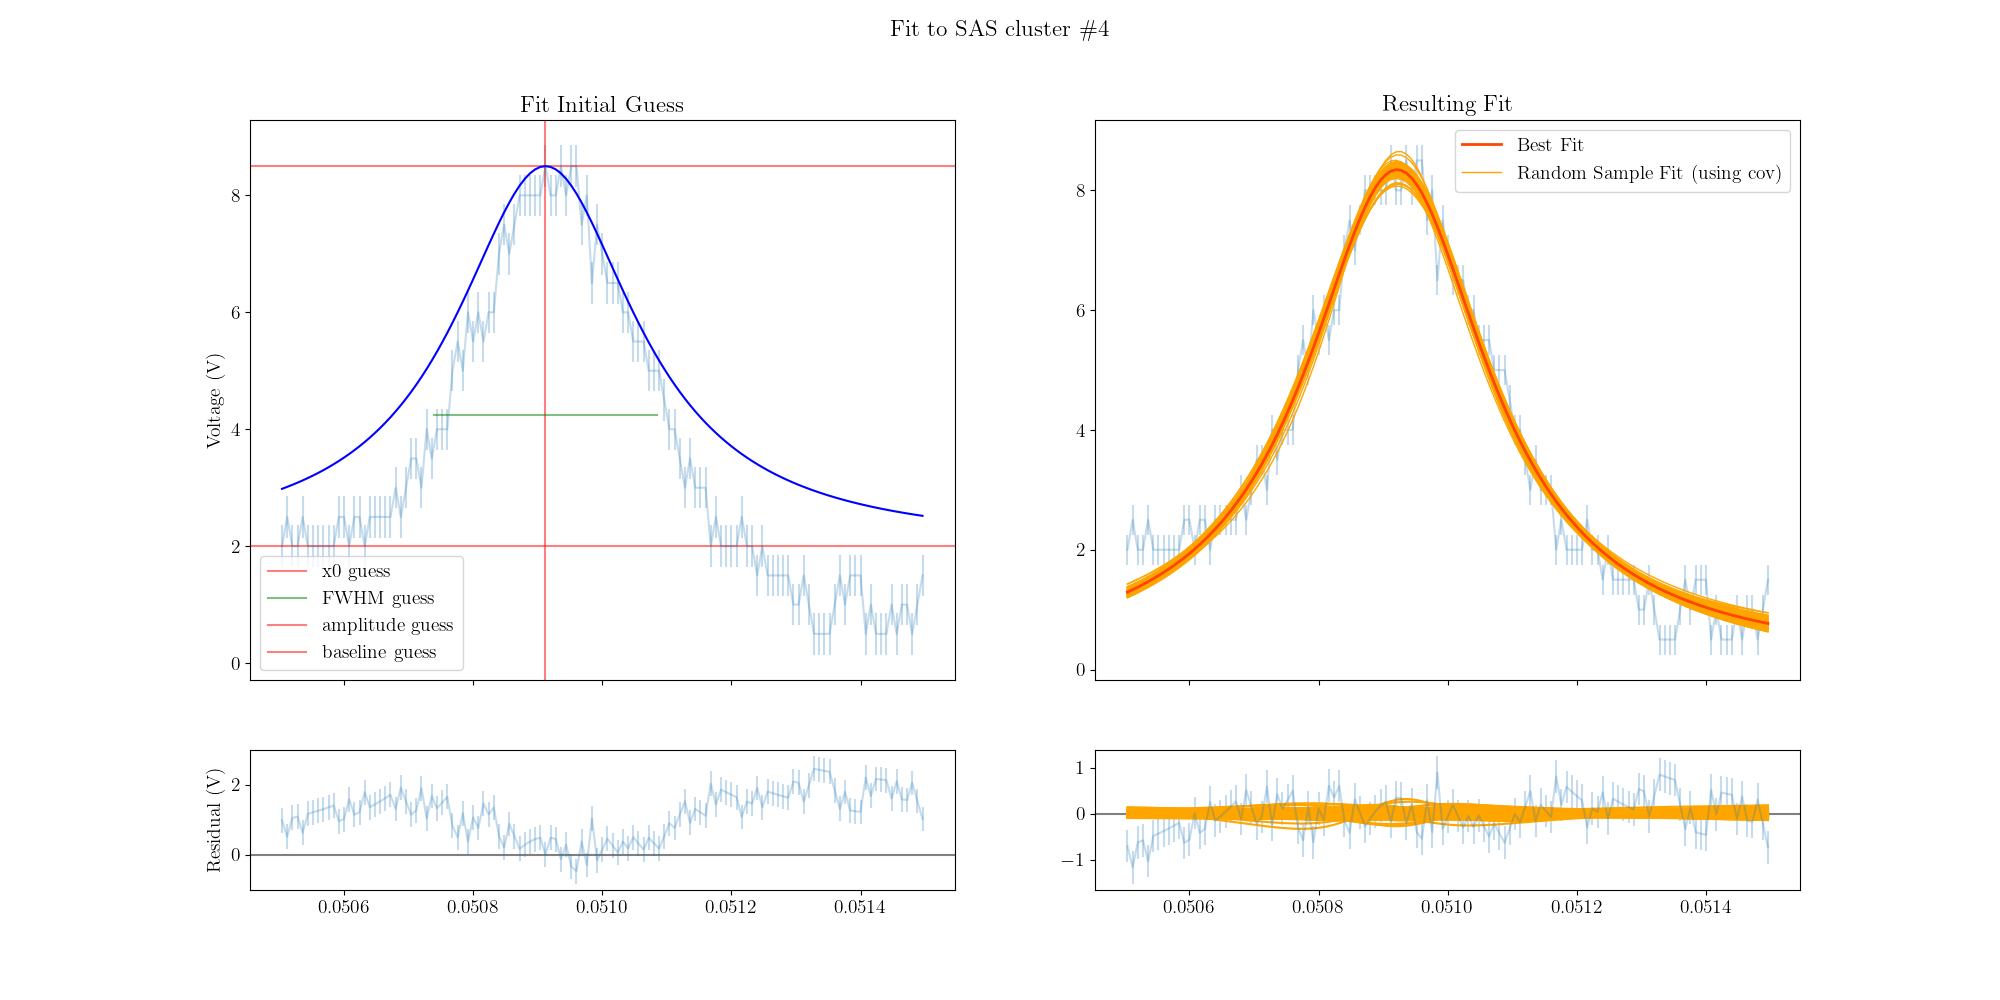

In [15]:
fit_spike(.0505, .0515, 3)

In [19]:
df = pd.DataFrame(spike_data).sort_values('center_time').reset_index(drop=True)
df

,center_time,e_center_time,amplitude,cluster_id
0,-0.020974,0.000007,1.712661,0
1,-0.019152,0.000002,5.707674,0
2,-0.018123,0.000003,4.160070,0
3,0.000447,0.000007,5.814719,1
4,0.035380,0.000015,2.865953,2
5,0.036125,0.000003,11.604647,2
6,0.036487,0.000003,13.640319,2
7,0.048479,0.000004,3.233247,3
8,0.050029,0.000001,10.764609,3
9,0.050921,0.000002,8.263249,3


In [22]:
df.to_csv('sas_spike_data_time.csv', index=False)